In [1]:
import pandas as pd
import re
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import seaborn as sns

None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [ ]:
# 1. 데이터 로딩 및 토크나이저 설정
df = pd.read_csv("./preprocess_1/preprocess_1.csv", index_col=0)

tokenizer_name = "skt/kogpt2-base-v2"
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

# 2. 텍스트 클리닝 함수 정의
def clean_diary_text(text):
    if not isinstance(text, str):
        return ""
    
    # HTML 태그 및 URL 제거
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', ' ', text)
    
    # 자음/모음 및 문장 부호 반복 압축
    text = re.sub(r'([ㄱ-ㅎㅏ-ㅣ])\1{2,}', r'\1\1', text) # ㅠㅠㅠㅠ -> ㅠㅠ
    text = re.sub(r'\.{3,}', '...', text)
    text = re.sub(r'\?{2,}', '??', text)
    text = re.sub(r'!{2,}', '!!', text)
    text = re.sub(r'~{2,}', '~', text)
    
    # 공백 및 개행 처리
    text = re.sub(r'[\n\t\r]+', ' ', text) # 개행/탭을 공백으로
    text = re.sub(r'\s{2,}', ' ', text)    # 다중 공백을 단일 공백으로
    
    return text.strip()

# 3. 데이터 전처리 및 필터링
# 3-1. 텍스트 클리닝 적용
df['Clean_Diary'] = df['content'].apply(clean_diary_text)


# 3-2. 결측치 제거 (PHQ-9 점수 기준)
n_before = len(df)
df = df.dropna(subset=["phq9_score"]).copy()
if len(df) < n_before:
    print(f"PHQ-9 결측으로 제거된 행: {n_before - len(df)}")

# 3-3. 기본 필터링 (너무 짧은 텍스트 제거)
df = df[df['Clean_Diary'].str.len() > 10].copy()

# 4. 통계 및 파생 변수 생성
# 4-1. 글자 수 계산
df['char_length'] = df['Clean_Diary'].str.len()

# 4-2. 토큰 수 계산 (KoGPT2 기준)
def count_tokens(text):
    return len(tokenizer.encode(text))

df['token_length'] = df['Clean_Diary'].apply(count_tokens)

# 4-3. Target Labeling
# 기준 1) 11점 이상 (High) = 1
df["phq9_high"] = (df["phq9_score"] > 11).astype(int)
# 기준 2) 11점 이하 (Low or Equal) = 1
df["phq9_loweq11"] = (df["phq9_score"] <= 11).astype(int)


--- 토큰 수(token_length) 상세 통계 ---
count    1682.000000
mean      242.898930
std       254.319379
min         4.000000
25%        76.250000
50%       155.000000
75%       307.000000
90%       571.600000
95%       799.700000
99%      1234.190000
max      1463.000000
Name: token_length, dtype: float64

[사분위수 상세]
1사분위수(Q1): 76.25
2사분위수(중앙값, Q2): 155.00
3사분위수(Q3): 307.00


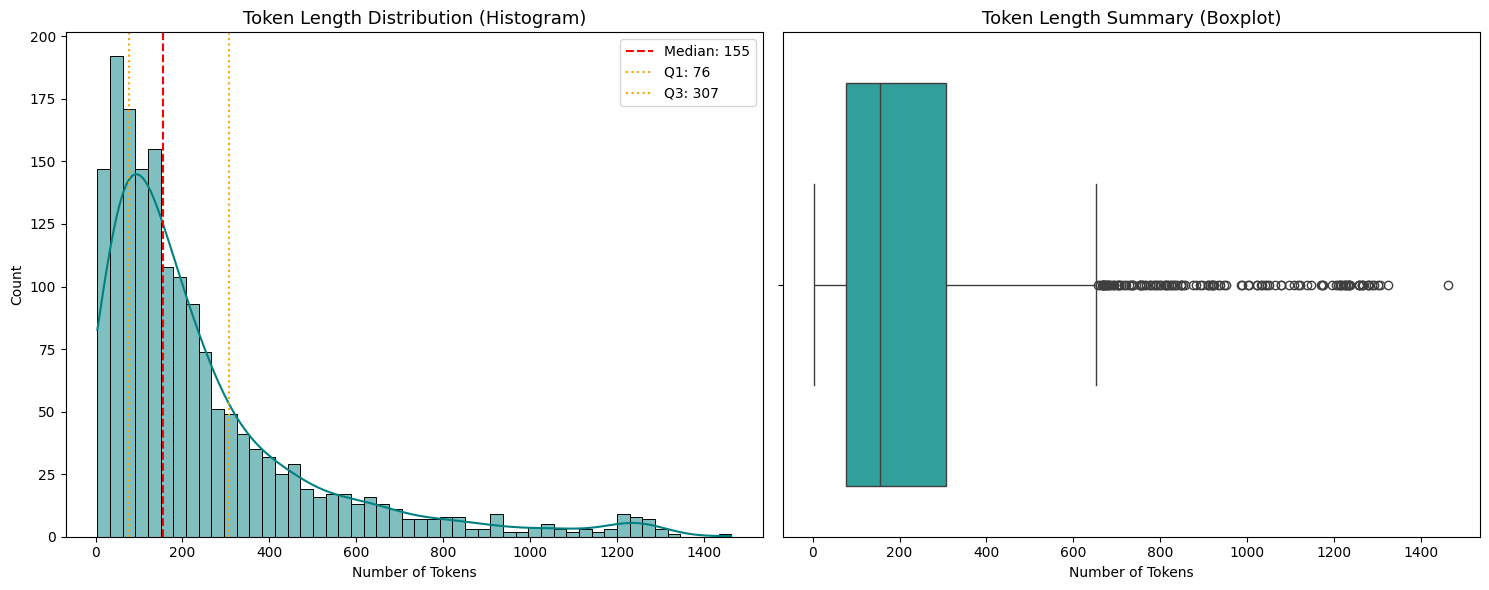

In [ ]:
# 5. 토큰 수(token_length) 통계 확인 (4분위수 포함)
print("--- 토큰 수(token_length) 상세 통계 ---")
stats = df['token_length'].describe(percentiles=[.25, .5, .75, .9, .95, .99])
print(stats)

# 구체적인 사분위수 값 따로 출력
print(f"\n[사분위수 상세]")
print(f"1사분위수(Q1): {stats['25%']:.2f}")
print(f"2사분위수(중앙값, Q2): {stats['50%']:.2f}")
print(f"3사분위수(Q3): {stats['75%']:.2f}")

# 6. 토큰 수 분포 시각화
plt.figure(figsize=(15, 6))

# (1) 히스토그램 & KDE (전체적인 분포 형태)
plt.subplot(1, 2, 1)
sns.histplot(df['token_length'], bins=50, kde=True, color='teal')
plt.axvline(stats['50%'], color='red', linestyle='--', label=f"Median: {stats['50%']:.0f}")
plt.axvline(stats['25%'], color='orange', linestyle=':', label=f"Q1: {stats['25%']:.0f}")
plt.axvline(stats['75%'], color='orange', linestyle=':', label=f"Q3: {stats['75%']:.0f}")
plt.title('Token Length Distribution (Histogram)', fontsize=13)
plt.xlabel('Number of Tokens')
plt.ylabel('Count')
plt.legend()

# (2) 박스플롯 (사분위수 및 이상치 확인)
plt.subplot(1, 2, 2)
sns.boxplot(x=df['token_length'], color='lightseagreen')
plt.title('Token Length Summary (Boxplot)', fontsize=13)
plt.xlabel('Number of Tokens')

plt.tight_layout()
plt.show()

In [ ]:
final_df = df[(df['token_length'] >= 50) & (df['token_length'] <= 700)].copy()

In [ ]:
final_df.to_csv("./preprocess_2/preprocess_2.csv")